## 2. Classification

In this section, we build classification models to predict the severity level of COVID-19 healthcare strain, represented by the variable `hospitalization_need` (categorized as Low, Medium, or High). The goal is to classify each day based on recent pandemic indicators and assess which features are most predictive of hospitalization demand.

We evaluate and compare two models:
- **Logistic Regression**: A simple and interpretable baseline model.
- **Random Forest Classifier**: A more flexible ensemble model that handles non-linear patterns and provides feature importance.

We use accuracy, macro-F1 score, and confusion matrices to assess performance, and apply 5-fold cross-validation for reliable generalization estimates.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
df = pd.read_csv("owid_covid_data_us_subset.csv")
df.head()

,date,total_cases,new_cases,total_deaths,new_deaths,total_cases_per_million,total_deaths_per_million,icu_patients,hosp_patients,weekly_hosp_admissions,daily_case_change_rate,daily_death_change_rate,hospitalization_rate,icu_rate,case_fatality_rate,7day_avg_new_cases,7day_avg_new_deaths,hospitalization_need,icu_requirement
0,2020-07-21,3853351.0,60012.0,145801.0,932.0,11390.679,430.994,11458.0,42195.0,30552.0,NaN,NaN,1.095021,0.297352,3.783746,NaN,NaN,High,High
1,2020-07-22,3911870.0,58519.0,146668.0,867.0,11563.663,433.557,12487.0,46107.0,31352.0,1.518652,0.594646,1.178643,0.319208,3.749307,NaN,NaN,High,High
2,2020-07-23,3975206.0,63336.0,147861.0,1193.0,11750.887,437.084,13916.0,47834.0,31679.0,1.619072,0.813402,1.203309,0.350070,3.719581,NaN,NaN,High,High
3,2020-07-24,4047622.0,72416.0,149052.0,1191.0,11964.952,440.604,13627.0,46748.0,31870.0,1.821692,0.805486,1.154950,0.336667,3.682458,NaN,NaN,High,High
4,2020-07-25,4120764.0,73142.0,150306.0,1254.0,12181.163,444.311,14402.0,51831.0,32804.0,1.807036,0.841317,1.257801,0.349498,3.647527,NaN,NaN,High,High


In [4]:
# Convert date column
df['date'] = pd.to_datetime(df['date'])

# Forward fill and drop remaining NA values in key columns
df.ffill(inplace=True)
df.dropna(subset=[
    '7day_avg_new_cases', '7day_avg_new_deaths',
    'daily_case_change_rate', 'daily_death_change_rate',
    'icu_patients', 'hosp_patients', 'hospitalization_need'
], inplace=True)


In [5]:
# Make sure target is categorical
df['hospitalization_need'] = df['hospitalization_need'].astype('category')

# Define features and label
features = [
    'daily_case_change_rate', 'daily_death_change_rate',
    '7day_avg_new_cases', '7day_avg_new_deaths',
    'icu_patients', 'hosp_patients'
]

X = df[features]
y = df['hospitalization_need']

### Scale Features and Split Data

In [7]:
# Scale the feature data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split into training and testing sets (80/20) with stratification
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

### Logistic Regression and Random Forest Classifier

In [ ]:
log_model = LogisticRegression(
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

log_model.fit(X_train, y_train)
y_pred_log = log_model.predict(X_test)


rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

# Logistic Regression Performance
print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_log))
print("\nLogistic Regression Report:\n", classification_report(y_test, y_pred_log))

# Random Forest Performance
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nRandom Forest Report:\n", classification_report(y_test, y_pred_rf))

🔵 Logistic Regression Accuracy: 0.912621359223301

🔵 Logistic Regression Report:
               precision    recall  f1-score   support

        High       0.96      0.94      0.95        70
         Low       0.88      0.97      0.92        68
      Medium       0.90      0.82      0.86        68

    accuracy                           0.91       206
   macro avg       0.91      0.91      0.91       206
weighted avg       0.91      0.91      0.91       206

🟢 Random Forest Accuracy: 0.9854368932038835

🟢 Random Forest Report:
               precision    recall  f1-score   support

        High       1.00      0.99      0.99        70
         Low       0.99      0.99      0.99        68
      Medium       0.97      0.99      0.98        68

    accuracy                           0.99       206
   macro avg       0.99      0.99      0.99       206
weighted avg       0.99      0.99      0.99       206



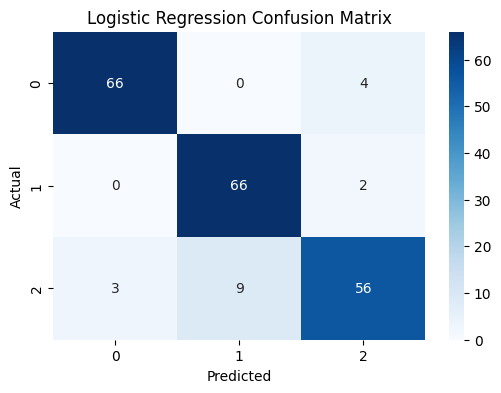

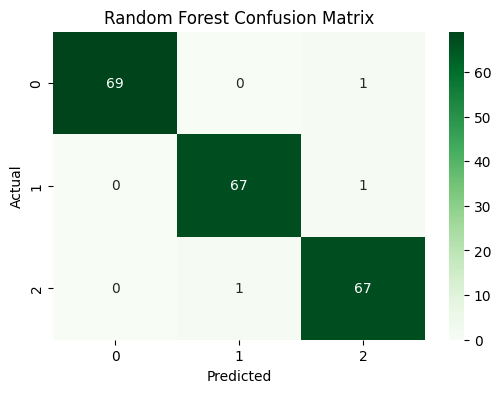

In [15]:
# Confusion matrix for Logistic Regression
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_log), annot=True, fmt='d', cmap='Blues')
plt.title("Logistic Regression Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# Confusion matrix for Random Forest
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d', cmap='Greens')
plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

### K-Fold Cross-Validation and Feature Importance

In [ ]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# Logistic Regression Cross-Val (Macro F1)
log_cv_score = cross_val_score(log_model, X_scaled, y, cv=cv, scoring='f1_macro')
print("Logistic Regression CV Macro-F1:", log_cv_score.mean())

# Random Forest Cross-Val (Macro F1)
rf_cv_score = cross_val_score(rf_model, X_scaled, y, cv=cv, scoring='f1_macro')
print("Random Forest CV Macro-F1:", rf_cv_score.mean())

🔵 Logistic Regression CV Macro-F1: 0.905660392429974
🟢 Random Forest CV Macro-F1: 0.9747037751349314


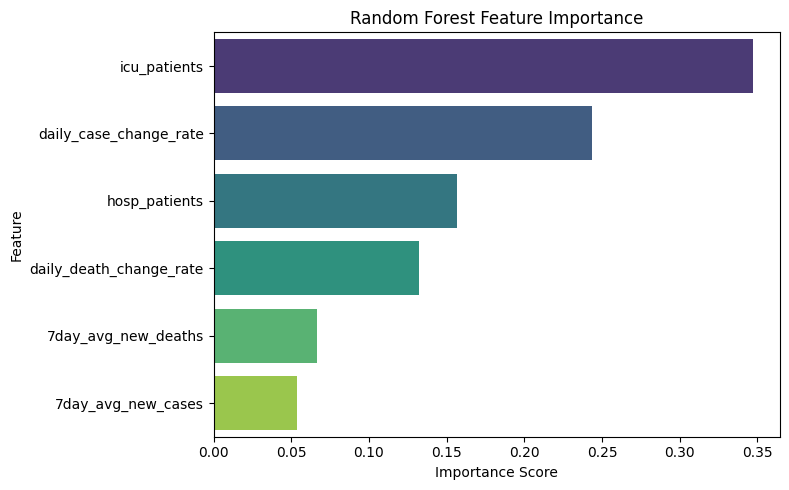

In [18]:
# DataFrame of feature importances for Random Forest
importances = rf_model.feature_importances_
feature_names = X.columns

feature_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(
    x='Importance',
    y='Feature',
    data=feature_df,
    hue='Feature',
    palette='viridis',
    legend=False
)
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

